<a href="https://colab.research.google.com/github/cathdong66-lgtm/EMSC2010-W10-L1/blob/main/emsc2010_w10_l1_nb4_uxxxxxxx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [1]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [2]:
file = 'blossom_doy.xlsx' #define the name of the data file
df = pd.read_excel(file) #read the file into a dataframe
df.head() #show the dataframe header

,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


In [9]:
df_blossom = df[['year', 'doy']].copy() #new dateframe with the variables we need
df_blossom = df_blossom.dropna() #remove rows with missing values
year = df_blossom['year'].to_numpy() #convert dates into numpy array
doy = df_blossom['doy'].to_numpy() #convert co2 into numpy array

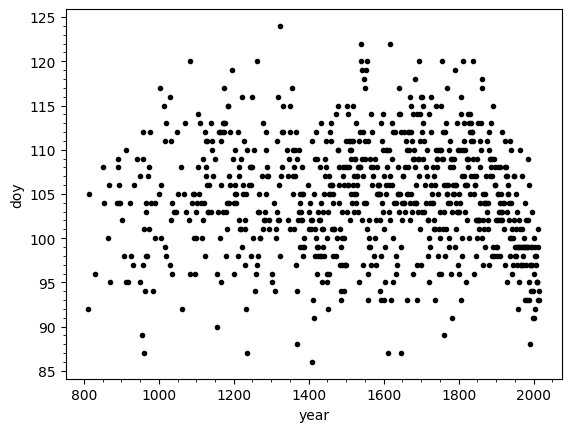

In [47]:
plt.plot(year, doy,'.k') #plot the data
plt.xlabel('year') #label the x-axis
plt.ylabel('doy') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

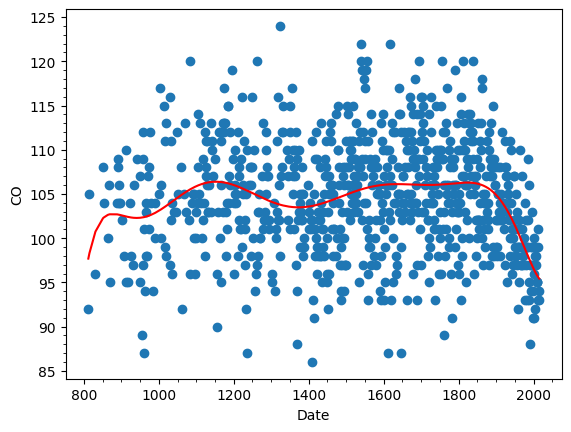

In [39]:
order = 10 #set the polynomial order
pp = np.polyfit(year,doy,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

plt.scatter(year,doy) #plot the data
plt.plot(year,trend,'r') #plot the trend
plt.xlabel('Date') #label the x-axis
plt.ylabel('CO') #label the y-axis
plt.minorticks_on() #add minorticks to the plot


In [29]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [45]:
w = 91 #length of the moving average
ys = moving_average(doy, w) #process the signal
ts = moving_average(year, w) #process the times

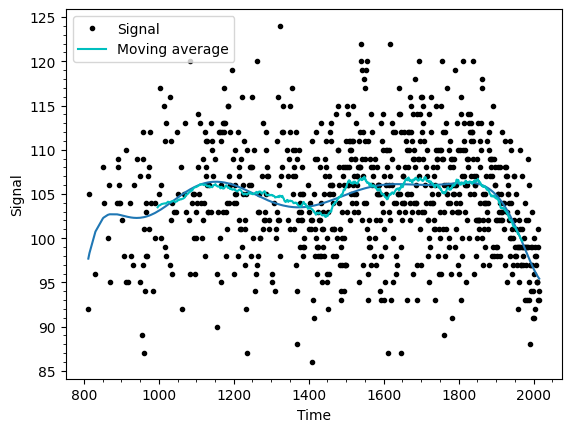

In [46]:
plt.plot(year,doy,'.k',linewidth=0.5,label='Signal') #plot the noisy signal
plt.plot(year,trend)
plt.plot(ts,ys,'c',label='Moving average') #plot the moving average

plt.xlabel('Time') #label the x-axis
plt.ylabel('Signal') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks